In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import xgboost as xgb

In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\DELL\Downloads\archive (2)\BMW_Car_Sales_Classification.csv")
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [3]:
df.drop_duplicates()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [4]:
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [5]:
print(df.dtypes)

Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object


In [6]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [7]:
X = df.drop(['Sales_Classification', 'Sales_Volume'], axis=1)

le = LabelEncoder()
y = le.fit_transform(df['Sales_Classification'])

categorical_features = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_final = preprocessor.fit_transform(X_train)
X_test_final  = preprocessor.transform(X_test)

print("Train shape:", X_train_final.shape)
print("Test shape :", X_test_final.shape)

Train shape: (40000, 33)
Test shape : (10000, 33)


In [8]:
model_initial = RandomForestClassifier(n_estimators=100, random_state=42)
model_initial.fit(X_train_final, y_train)

acc_before = accuracy_score(y_test, model_initial.predict(X_test_final))
print(f"RF Accuracy BEFORE feature selection: {acc_before * 100:.2f}%")

RF Accuracy BEFORE feature selection: 68.47%


In [14]:
best_k   = 0
best_acc = 0

for k in [10, 15, 20, 25, 30, 33]:
    sel = SelectKBest(score_func=mutual_info_classif, k=k)
    Xtr = sel.fit_transform(X_train_final, y_train)
    Xte = sel.transform(X_test_final)
    model = RandomForestClassifier(n_estimators=500, random_state=42)
    model.fit(Xtr, y_train)
    acc = accuracy_score(y_test, model.predict(Xte))
    print(f"k={k:>2}  →  {acc*100:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_k   = k

print(f"\n✅ Best k = {best_k}  →  {best_acc*100:.2f}%")

k=10  →  69.68%
k=15  →  69.37%
k=20  →  67.06%
k=25  →  68.91%
k=30  →  68.96%
k=33  →  69.08%

✅ Best k = 10  →  69.68%


In [15]:
selector = SelectKBest(score_func=mutual_info_classif, k=best_k)
X_train_selected = selector.fit_transform(X_train_final, y_train)
X_test_selected  = selector.transform(X_test_final)

model_final = RandomForestClassifier(n_estimators=500, random_state=42)
model_final.fit(X_train_selected, y_train)
acc_improved = accuracy_score(y_test, model_final.predict(X_test_selected))
print(f"RF Accuracy AFTER : {acc_improved * 100:.2f}%")


RF Accuracy AFTER : 69.65%


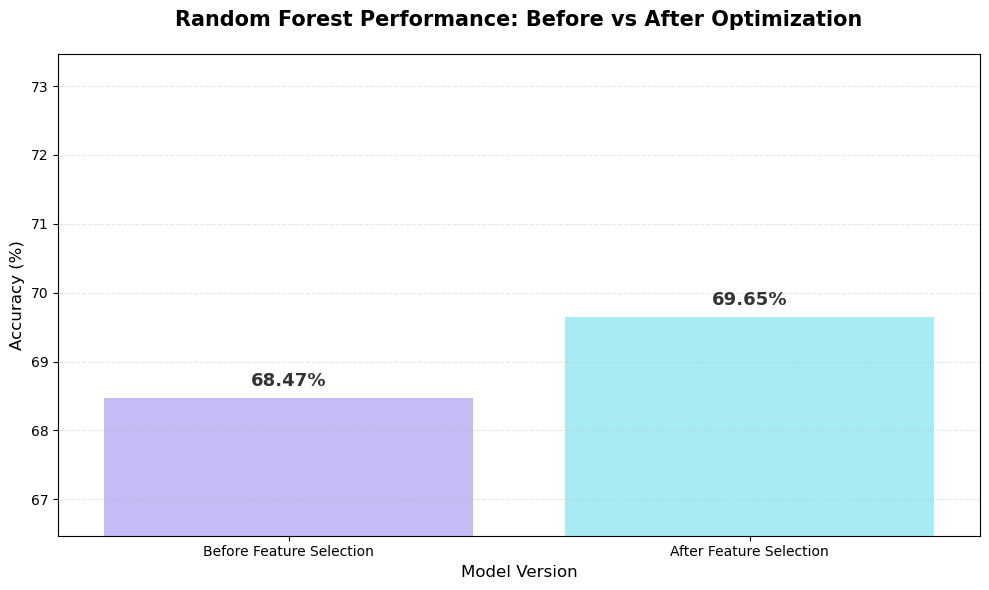


Before : 68.47%
After  : 69.65%
Change : +1.18%


In [16]:
rf_labels     = ['Before Feature Selection', 'After Feature Selection']
rf_accuracies = [acc_before * 100, acc_improved * 100]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rf_labels, y=rf_accuracies,
                 hue=rf_labels, palette=['#BDB2FF', '#9BF6FF'], legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 12),
                textcoords='offset points',
                fontweight='bold', fontsize=13, color='#333333')

plt.title('Random Forest Performance: Before vs After Optimization',
          fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model Version', fontsize=12)

min_val = min(rf_accuracies)
plt.ylim(min_val - 2, min_val + 5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBefore : {acc_before  * 100:.2f}%")
print(f"After  : {acc_improved * 100:.2f}%")
print(f"Change : +{(acc_improved - acc_before) * 100:.2f}%")


In [17]:
le2 = LabelEncoder()
y_train_encoded = le2.fit_transform(y_train)
y_test_encoded  = le2.transform(y_test)

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train_final, y_train_encoded)

y_pred_xgb = model_xgb.predict(X_test_final)
acc_xgb    = accuracy_score(y_test_encoded, y_pred_xgb)

print(f"XGBoost Accuracy BEFORE feature selection: {acc_xgb * 100:.2f}%")


XGBoost Accuracy BEFORE feature selection: 68.19%


In [18]:
importances  = model_xgb.feature_importances_
indices      = np.argsort(importances)[::-1]

print("Top features by importance:")
for f in range(min(10, X_train_final.shape[1])):
    print(f"  {f+1}. {all_feature_names[indices[f]]:40s}  {importances[indices[f]]:.4f}")

Top features by importance:
  1. cat__Model_M3                             0.0371
  2. cat__Model_3 Series                       0.0352
  3. cat__Model_M5                             0.0345
  4. cat__Region_South America                 0.0344
  5. cat__Model_i8                             0.0338
  6. cat__Region_North America                 0.0334
  7. cat__Fuel_Type_Hybrid                     0.0332
  8. cat__Model_5 Series                       0.0331
  9. cat__Color_Black                          0.0330
  10. cat__Transmission_Automatic               0.0328


In [19]:
selector_xgb = SelectFromModel(model_xgb, threshold='median', prefit=True)
X_train_selected_xgb = selector_xgb.transform(X_train_final)
X_test_selected_xgb  = selector_xgb.transform(X_test_final)

print(f"Features reduced: {X_train_final.shape[1]} → {X_train_selected_xgb.shape[1]}")

model_xgb_selected = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_selected.fit(X_train_selected_xgb, y_train_encoded)

y_pred_selected = model_xgb_selected.predict(X_test_selected_xgb)
acc_after       = accuracy_score(y_test_encoded, y_pred_selected)

print(f"XGBoost Accuracy AFTER  feature selection: {acc_after * 100:.2f}%")


Features reduced: 33 → 17
XGBoost Accuracy AFTER  feature selection: 69.47%


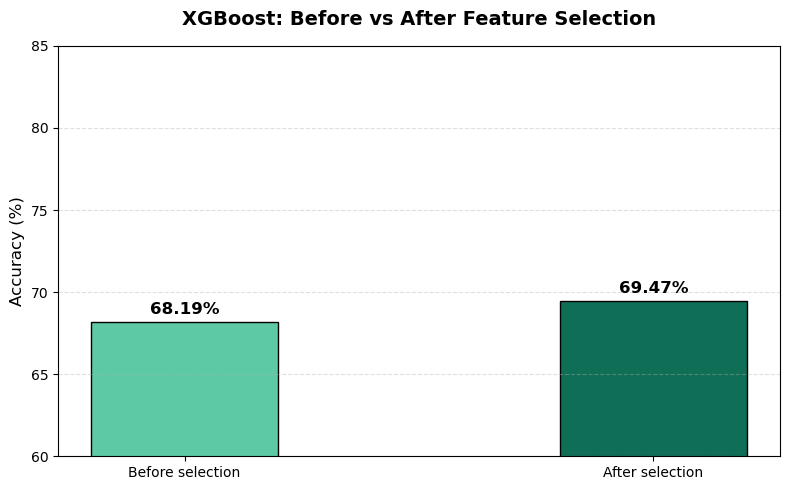

In [20]:
xgb_labels     = ['Before selection', 'After selection']
xgb_accuracies_plot = [acc_xgb * 100, acc_after * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(xgb_labels, xgb_accuracies_plot,
               color=['#5DCAA5', '#0F6E56'], edgecolor='black', width=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5,
             f'{yval:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('XGBoost: Before vs After Feature Selection',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(60, 85)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

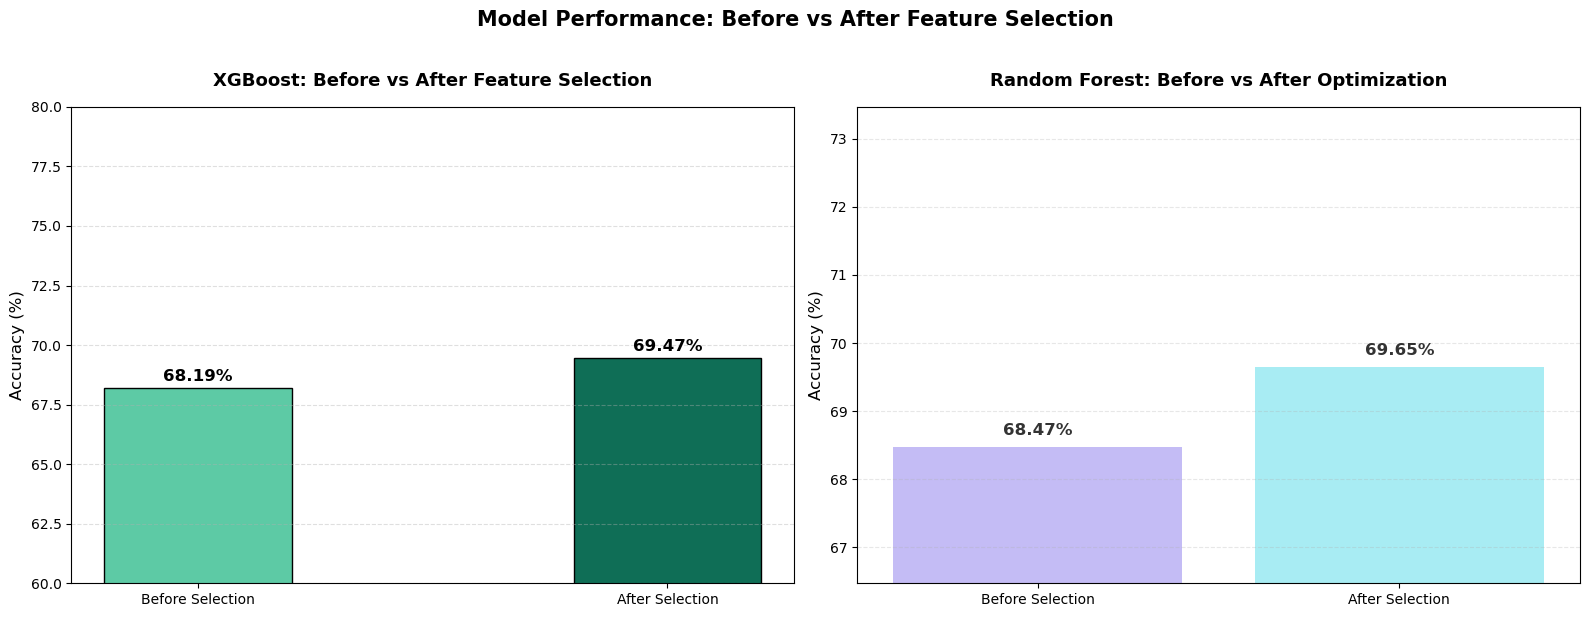

XGBoost  → Before: 68.19%  |  After: 69.47%  |  Change: +1.28%
RF       → Before: 68.47%  |  After: 69.65%  |  Change: +1.18%


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

xgb_labels          = ['Before Selection', 'After Selection']
xgb_accuracies_plot = [acc_xgb * 100, acc_after * 100]

bars = ax1.bar(xgb_labels, xgb_accuracies_plot,
               color=['#5DCAA5', '#0F6E56'], edgecolor='black', width=0.4)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, yval + 0.3,
             f'{yval:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax1.set_title('XGBoost: Before vs After Feature Selection',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(60, 80)
ax1.grid(axis='y', linestyle='--', alpha=0.4)


rf_labels     = ['Before Selection', 'After Selection']
rf_accuracies = [acc_before * 100, acc_improved * 100]

sns.barplot(x=rf_labels, y=rf_accuracies,
            hue=rf_labels, palette=['#BDB2FF', '#9BF6FF'],
            legend=False, ax=ax2)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 12),
                 textcoords='offset points',
                 fontweight='bold', fontsize=12, color='#333333')

ax2.set_title('Random Forest: Before vs After Optimization',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
min_val = min(rf_accuracies)
ax2.set_ylim(min_val - 2, min_val + 5)
ax2.grid(axis='y', linestyle='--', alpha=0.3)


fig.suptitle('Model Performance: Before vs After Feature Selection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"XGBoost  → Before: {acc_xgb*100:.2f}%  |  After: {acc_after*100:.2f}%  |  Change: +{(acc_after-acc_xgb)*100:.2f}%")
print(f"RF       → Before: {acc_before*100:.2f}%  |  After: {acc_improved*100:.2f}%  |  Change: +{(acc_improved-acc_before)*100:.2f}%")

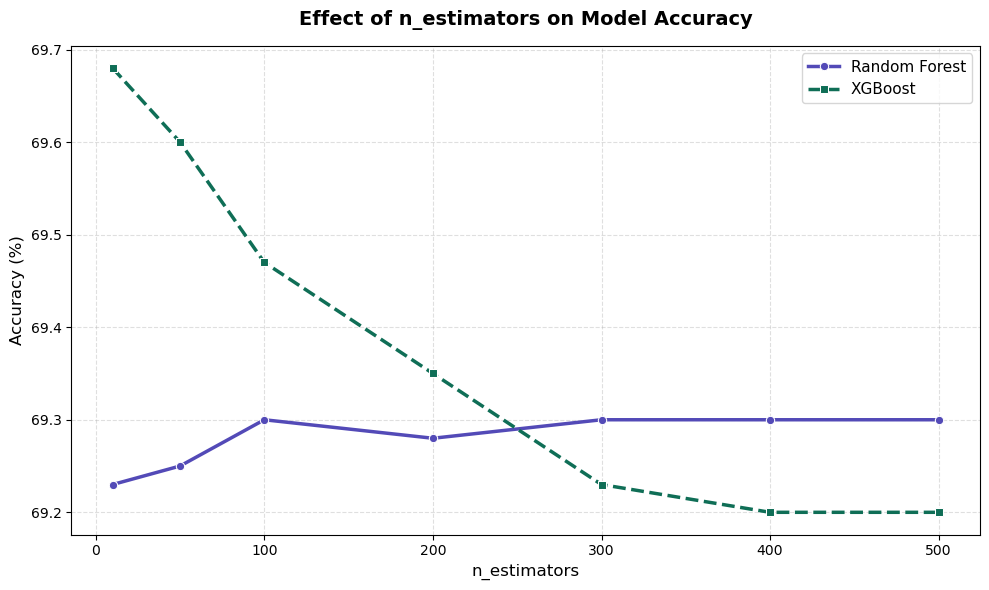

In [21]:
xgb_selected_names = all_feature_names[selector_xgb.get_support()]

n_estimators_range = [10, 50, 100, 200, 300, 400, 500]
rf_acc_list  = []
xgb_acc_list = []

for n in n_estimators_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_tmp.fit(X_train_selected_xgb, y_train)
    rf_acc_list.append(accuracy_score(y_test, rf_tmp.predict(X_test_selected_xgb)))

    xgb_tmp = xgb.XGBClassifier(n_estimators=n, random_state=42, eval_metric='logloss')
    xgb_tmp.fit(X_train_selected_xgb, y_train_encoded)
    xgb_acc_list.append(accuracy_score(y_test_encoded, xgb_tmp.predict(X_test_selected_xgb)))

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=[v*100 for v in rf_acc_list],
             marker='o', label='Random Forest', color='#534AB7', linewidth=2.5)
sns.lineplot(x=n_estimators_range, y=[v*100 for v in xgb_acc_list],
             marker='s', label='XGBoost',       color='#0F6E56', linewidth=2.5, linestyle='--')

plt.title('Effect of n_estimators on Model Accuracy',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('n_estimators', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

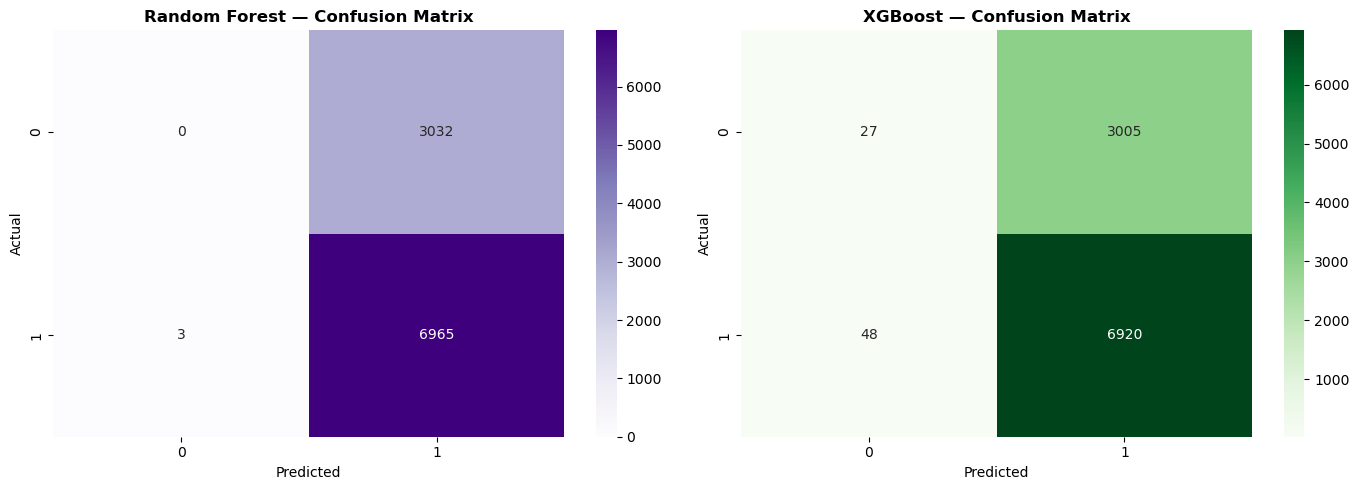

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectFromModel

selector_xgb = SelectFromModel(model_xgb, threshold='median', prefit=True)
X_test_selected_xgb = selector_xgb.transform(X_test_final)
X_train_selected_xgb = selector_xgb.transform(X_train_final)

y_pred_rf       = model_final.predict(X_test_selected)        
y_pred_selected = model_xgb_selected.predict(X_test_selected_xgb) 


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', ax=ax1, cmap='Purples')
ax1.set_title('Random Forest — Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_encoded, y_pred_selected),
            annot=True, fmt='d', ax=ax2, cmap='Greens')
ax2.set_title('XGBoost — Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

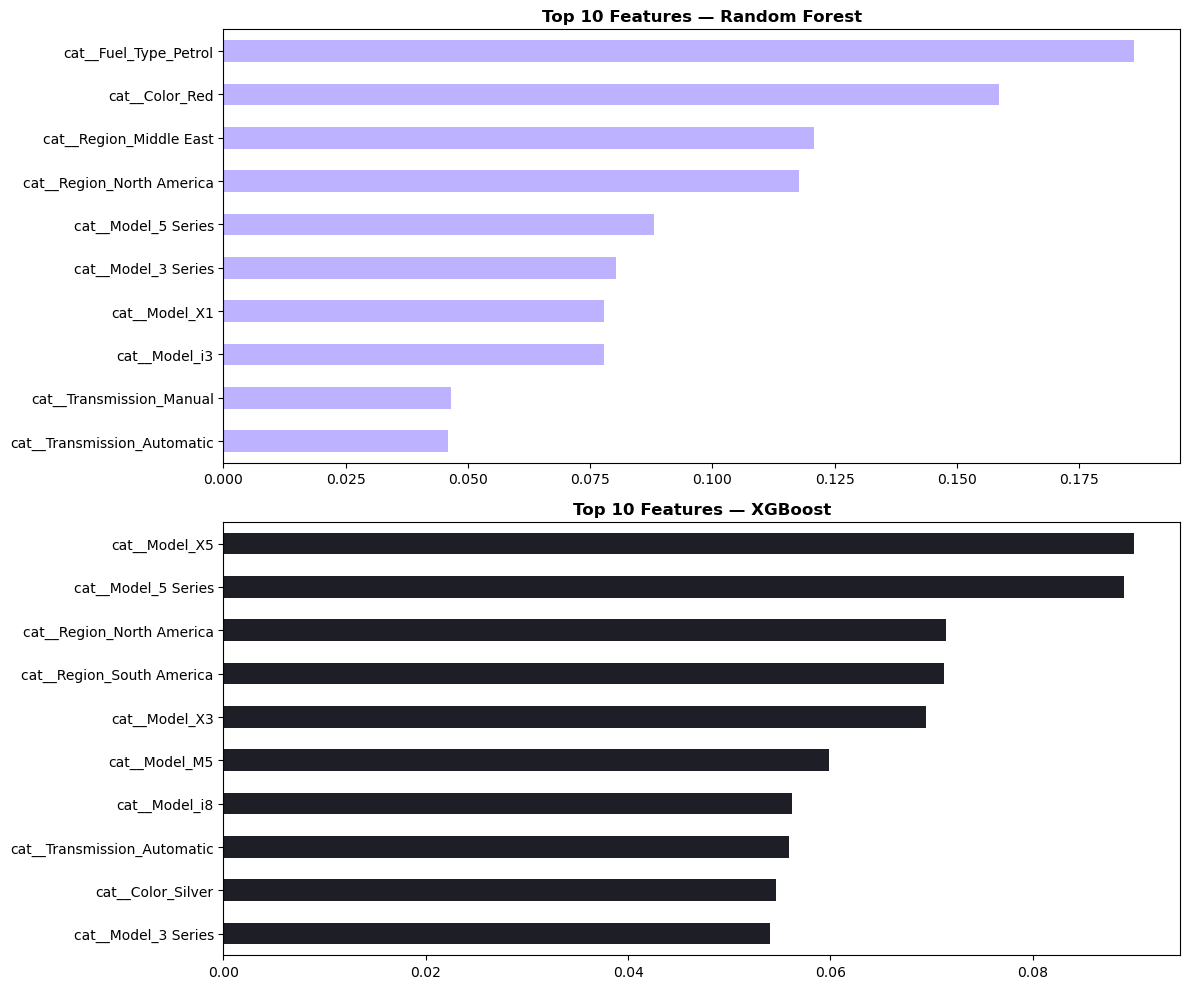

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

all_feature_names = preprocessor.get_feature_names_out()

rf_selected_names  = all_feature_names[selector.get_support()]
  
xgb_selected_names = all_feature_names[selector_xgb.get_support()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

pd.Series(model_final.feature_importances_, index=rf_selected_names)\
    .nlargest(10).plot(kind='barh', color='#BDB2FF', ax=ax1)
ax1.set_title('Top 10 Features — Random Forest', fontweight='bold')
ax1.invert_yaxis()

pd.Series(model_xgb_selected.feature_importances_, index=xgb_selected_names)\
    .nlargest(10).plot(kind='barh', color='#1e1e26', ax=ax2)
ax2.set_title('Top 10 Features — XGBoost', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

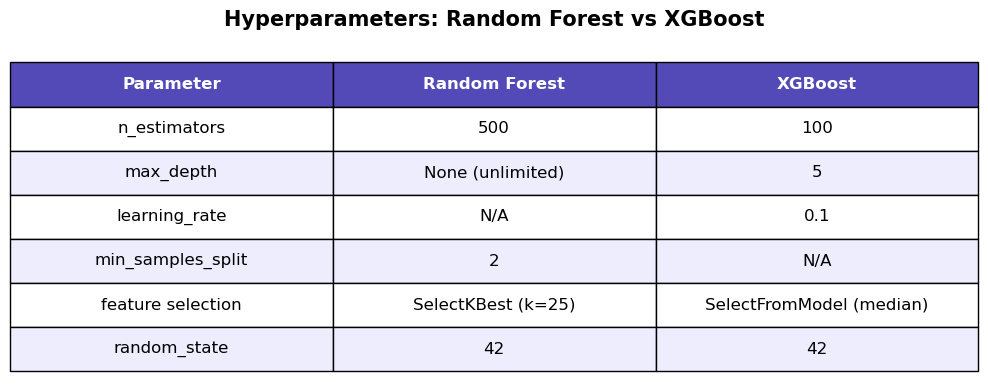

In [29]:
params_data = [
    ['Parameter',        'Random Forest',      'XGBoost'],
    ['n_estimators',     '500',                '100'],
    ['max_depth',        'None (unlimited)',    '5'],
    ['learning_rate',    'N/A',                '0.1'],
    ['min_samples_split','2',                  'N/A'],
    ['feature selection','SelectKBest (k=25)', 'SelectFromModel (median)'],
    ['random_state',     '42',                 '42'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(cellText=params_data, loc='center', cellLoc='center',
                 colWidths=[0.35, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#534AB7')
    elif row % 2 == 0:
        cell.set_facecolor('#EEEDFE')
    else:
        cell.set_facecolor('#ffffff')

plt.title('Hyperparameters: Random Forest vs XGBoost',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

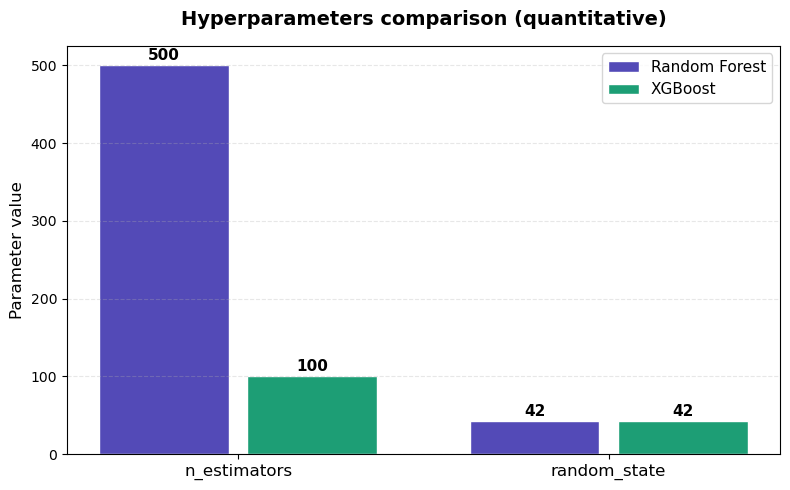

In [30]:
params_quant = ['n_estimators', 'max_depth (XGB)', 'random_state']
rf_vals  = [500,  None, 42]
xgb_vals = [100,  5,    42]

# Filter only numeric params
labels_q = ['n_estimators', 'random_state']
rf_q  = [500, 42]
xgb_q = [100, 42]

x2 = np.arange(len(labels_q))
fig, ax = plt.subplots(figsize=(8, 5))

rects_a = ax.bar(x2 - 0.2, rf_q,  0.35, label='Random Forest',
                 color='#534AB7', edgecolor='white')
rects_b = ax.bar(x2 + 0.2, xgb_q, 0.35, label='XGBoost',
                 color='#1D9E75', edgecolor='white')

for rect in list(rects_a) + list(rects_b):
    h = rect.get_height()
    ax.annotate(str(int(h)),
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontweight='bold', fontsize=11)

ax.set_xticks(x2)
ax.set_xticklabels(labels_q, fontsize=12)
ax.set_ylabel('Parameter value', fontsize=12)
ax.set_title('Hyperparameters comparison (quantitative)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
print("\n" + "="*50)
print("FINAL ACCURACY SUMMARY")
print("="*50)
print(f"  Random Forest  — Before selection : {acc_before   * 100:.2f}%")
print(f"  Random Forest  — After  selection : {acc_improved * 100:.2f}%  (Δ {(acc_improved - acc_before)*100:+.2f}%)")
print(f"  XGBoost        — Before selection : {acc_xgb      * 100:.2f}%")
print(f"  XGBoost        — After  selection : {acc_after    * 100:.2f}%  (Δ {(acc_after - acc_xgb)*100:+.2f}%)")
print("="*50)
print("\nKey Hyperparameters:")
print("  RF  → n_estimators=500, max_depth=None, SelectKBest(k=25)")
print("  XGB → n_estimators=100, max_depth=5, lr=0.1, SelectFromModel(median)")
print("="*50)



FINAL ACCURACY SUMMARY
  Random Forest  — Before selection : 68.47%
  Random Forest  — After  selection : 69.65%  (Δ +1.18%)
  XGBoost        — Before selection : 68.19%
  XGBoost        — After  selection : 69.47%  (Δ +1.28%)

Key Hyperparameters:
  RF  → n_estimators=500, max_depth=None, SelectKBest(k=25)
  XGB → n_estimators=100, max_depth=5, lr=0.1, SelectFromModel(median)
